# Sampling and standard error

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Recalling inferential statistics

- We want to make inferences aobut the population but only looking at one or mor random samples drawn from that population 

- With monte carlo simulation we can generate lots of random samples, and use them to compute confidence intervals by calculating the statistics of those trails

- But what if we coun't? What polls and survers usually do? why they only have one sample and not hundreds of them?

## Probability sampling

- Each member of the population has non-zero probabilty of being included in a sample

- **simple random sampling**: each member has an equal chance of being chosen

- Not always appropiate when we don't consider the characteristics of the population and how they are distributed


## Stratified sampling:

- Partition population into subgroups

- take a sipmle random sample from each subgroup, this is important when there are small subgroups that should be represented , and when it is important that those subgruops to be represented proportinally to their size in the poopulation

- But, it rquries care to do properly and well stick to simple random samples

## Data 

-  We are using dara from NCEI , daily high and low temperatures for 21 differnent US cities, from 1961 through 2015, 421848 rows.


# Functions

In [25]:
x = None
if not x:
    print("xd")

xd


In [52]:
def makeHist(data, title, xlabel, ylabel, bins=20, ax=None):

    if ax is None:
        fig, ax = plt.subplots()

    ax.hist(data, bins=bins, color="#034794", alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [53]:
def getMeanAndSds(population, sample, verbose=False):

    popMean = sum(population) / len(population)

    sampleMean = sum(sample) / len(sample)

    if verbose:

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        makeHist(
            population,
            f"Daily High 1961 - 2015, Population \n \
                    mean = {round(popMean, 2)} Degrees C Number Days",
            "Degrees C",
            "Number Days",
            ax=axes[0],
        )
        makeHist(
            sample,
            f"Daily High 1961 - 2015, Sample \n \
                 (mean = {round(sampleMean, 2)}) ",
            "Degrees C",
            "Number Days",
            ax=axes[1],
        )
        plt.tight_layout()
        plt.show()
        print(f"Population mean = {popMean}")
        print(f"Standard deviation of population = {np.std(population)}")
        print(f"Sample Mean = {sampleMean} ")
        print(f"Standard deviation of sample = {np.std(sample)}")

    return popMean, sampleMean, np.std(population), np.std(sample)

In [54]:
## this can be totally done using pandas, but it is interesting to learn this methods


def getHighs():
    inFile = open("../data/temperatures.csv")
    population = []
    for l in inFile:
        try:
            tempC = float(l.split(",")[1])
            population.append(tempC)

        except:
            continue
    return population

# Reading the data

In [55]:
population = getHighs()
print(len(population))

421848


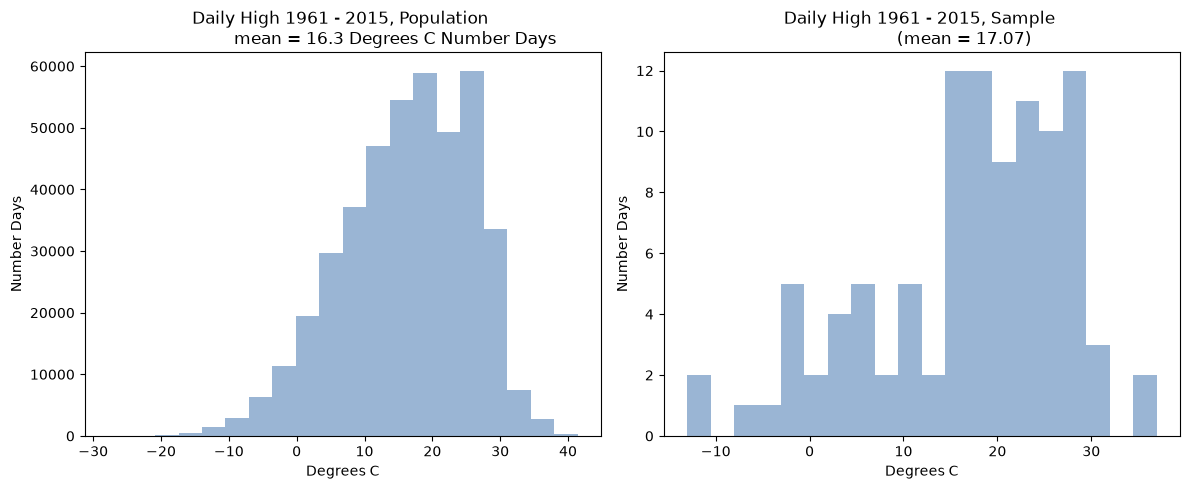

Population mean = 16.298769461986307
Standard deviation of population = 9.4375585448036
Sample Mean = 17.0685 
Standard deviation of sample = 10.390314372048614


In [56]:
random.seed(0)
sample = random.sample(population, 100)
popMean, sampleMean, stdPop, stdSample = getMeanAndSds(population, sample, True)

- Notice how the sample mean is not that far from the actual population mean!
- Lets try it 1000 times!

Mean of sample means = 16.294
Standard deviation pf sample means = 0.943


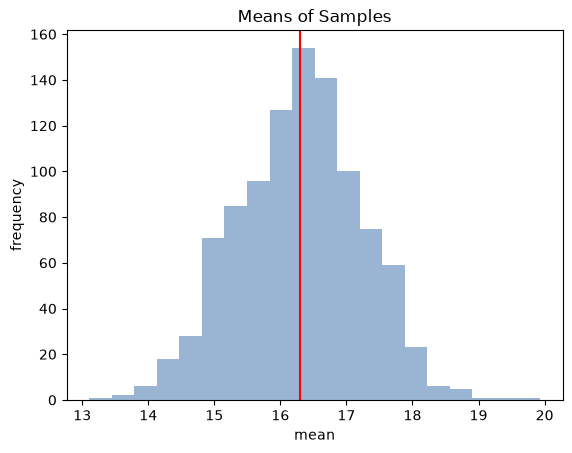

In [57]:
random.seed(0)
sampleSize = 100
numSamples = 1000
sampleMeans = []
for i in range(numSamples):
    sample = random.sample(population, sampleSize)
    popMean, sampleMean, popSD, sampleSD = getMeanAndSds(
        population, sample, verbose=False
    )
    sampleMeans.append(sampleMean)

print(f"Mean of sample means = {round(sum(sampleMeans)/ len(sampleMeans), 3)}")
print(f"Standard deviation pf sample means = {round(np.std(sampleMeans),3)}")

makeHist(sampleMeans, "Means of Samples", "mean", "frequency")
plt.axvline(x=popMean, color="r")
plt.show()

In [59]:
# lets compute confidence intervals:

upper = 16.294 + 1.96 * 0.943
lower = 16.294 - 1.96 * 0.943
print(upper, lower)

# includes the pop mean... but pretty wide!

18.14228 14.445720000000001
